## Image Classification with Deep Learning 

### Introduction
For our practical session, we are going to inplement on of the most common computer vision tasks- image classification. We will use the CIFAR-10 dataset. The CIFAR-10 dataset is a widely used collection of 60,000 small, 32x32 color images divided into 10 distinct object classes (like airplanes, cats, cars, dogs, ships, trucks) for training and testing computer vision models, with 50,000 images for training and 10,000 for testing, serving as a benchmark for algorithm performance in machine learning. 

For this task we will need to also install a new librarry called keras.So go ahead and run 
```pip install --upgrade keras``` on your terminal.


In [4]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### 1. Load & Explore the Data

In [5]:
from tensorflow.keras import datasets # type: ignore

(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train, test_size=0.2, random_state=42,stratify=y_train)
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(40000, 32, 32, 3) (10000, 32, 32, 3) (10000, 32, 32, 3) (40000, 1) (10000, 1) (10000, 1)


Let us confirm that the data looks correct and inspect a couple of images...

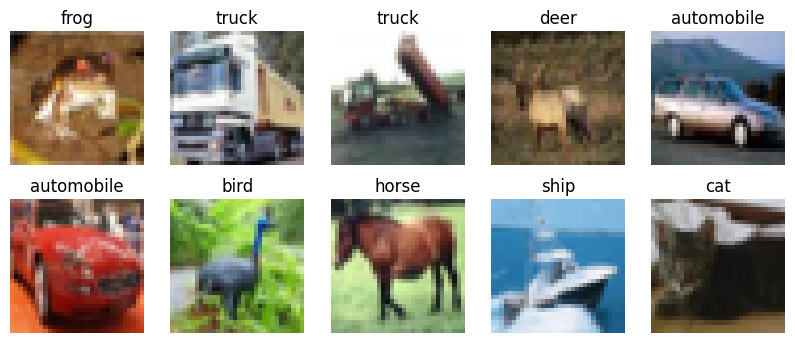

In [6]:
# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Display some sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])  
    plt.axis('off')
plt.show()

### 2. Image Pre-processing

**2.1 Normalization**

Remember, our images are represented as a grid of pixel values. Pixel values can range from between 0-255. If the input pixel values are large and widely varied, it means the network will have very large gradients and may not converge. So we normalize to limit shrink the pixel values between 0 and 1

In [7]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

Other pre-processing steps typical in computer vision is image augmentation. Here, you can flip images, rotate them, adjust their contrast, edge detection and so much more. But for this dataset, we have enough training samples, and we want to see the model performance first, then we can come back to make the decision on whether augmentation is actually necessary.

Explore the open CV library for methods used in image augmentation...

### 3. Model Building & Training

In [9]:
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Flatten # type: ignore


fcnn = Sequential()

#flattened input layer
fcnn.add(Flatten(input_shape=(32,32,3)))

#hidden layers
fcnn.add(Dense(1024, activation='relu'))
fcnn.add(Dense(512, activation='relu'))
fcnn.add(Dense(256, activation='relu'))

#output layer
fcnn.add(Dense(10, activation='softmax'))
print("Added Dense Output Layer (10 neurons, Softmax activation)")

# Display the model architecture summary
fcnn.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
fcnn.summary()

Added Dense Output Layer (10 neurons, Softmax activation)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
history = fcnn.fit(
    X_train, y_train,
    batch_size=52,
    epochs=5,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 55s 54ms/step - accuracy: 0.3216 - loss: 1.8780 - val_accuracy: 0.3528 - val_loss: 1.7780
Epoch 2/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.3992 - loss: 1.6715 - val_accuracy: 0.4139 - val_loss: 1.6170
Epoch 3/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 51s 53ms/step - accuracy: 0.4331 - loss: 1.5801 - val_accuracy: 0.4512 - val_loss: 1.5333
Epoch 4/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.4521 - loss: 1.5214 - val_accuracy: 0.4692 - val_loss: 1.4995
Epoch 5/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 51s 53ms/step - accuracy: 0.4682 - loss: 1.4802 - val_accuracy: 0.4823 - val_loss: 1.4486


Determining the appropriate number of epoch
Plot the training accuracy against the no. of epochs

In [12]:
#Model performance of the FCNN
loss, accuracy = fcnn.evaluate(X_val, y_val, verbose=0)

print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")


Final Validation Loss: 1.4486
Final Validation Accuracy: 0.4823


In [15]:
# Build a simple CNN model
cnn_model = models.Sequential([
    #cnn part
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),

    #fcnn part
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes
])

cnn_model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**Conv2D layer (Convolutional layer)**

- 32 filters → the layer will learn 32 different feature maps (like edges, textures).
(3,3) 
- kernel size → small 3x3 sliding window for detecting features.
- Activation='relu' → introduces non-linearity and helps the network learn complex patterns.
- input_shape=(32,32,3) → input images are 32x32 pixels with 3 color channels (RGB).

**Max Pooling layer**

Reduces the spatial size of feature maps by taking the maximum value in each 2x2 window.Helps reduce computation. After this, feature maps become smaller (half the height and width).

**Dense (fully connected) layer**

- 64 neurons, ReLU activation.Learns complex combinations of features extracted by convolutional layers.

**Output layer**

- 10 neurons → one for each CIFAR-10 class.
- Softmax activation → converts outputs into probabilities that sum to 1.The class with the highest probability is the model’s prediction.

In [16]:
history = cnn_model.fit(
    X_train, y_train,
    batch_size=52,
    epochs=5,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.4308 - loss: 1.5559 - val_accuracy: 0.5348 - val_loss: 1.2757
Epoch 2/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.5787 - loss: 1.1827 - val_accuracy: 0.6204 - val_loss: 1.0694
Epoch 3/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.6441 - loss: 1.0130 - val_accuracy: 0.6786 - val_loss: 0.9298
Epoch 4/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.6833 - loss: 0.9068 - val_accuracy: 0.7109 - val_loss: 0.8264
Epoch 5/5
962/962 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.7100 - loss: 0.8269 - val_accuracy: 0.7254 - val_loss: 0.7796


In [17]:
#Model performance of the CNN
loss, accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)

print("Performance Analysis of the CNN")
print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

Performance Analysis of the CNN

Final Validation Loss: 0.7796
Final Validation Accuracy: 0.7254


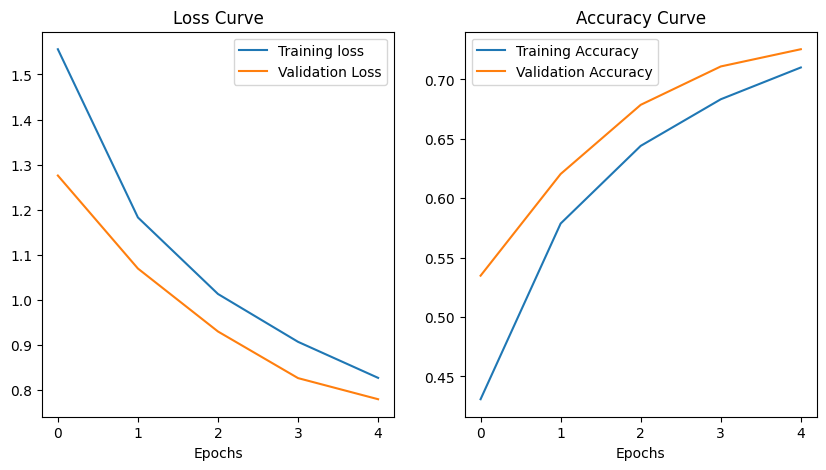

In [18]:
train_loss=history.history['loss']
val_loss=history.history['val_loss']
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(train_loss,label='Training loss')
plt.plot(val_loss,label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(122)
plt.plot(train_accuracy,label='Training Accuracy')
plt.plot(val_accuracy,label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.legend()


In [19]:
history = cnn_model.fit(
    X_train, y_train,
    batch_size=52,
    epochs=10,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.7361 - loss: 0.7614 - val_accuracy: 0.7491 - val_loss: 0.7369
Epoch 2/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7528 - loss: 0.7102 - val_accuracy: 0.7767 - val_loss: 0.6438
Epoch 3/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.7684 - loss: 0.6613 - val_accuracy: 0.8034 - val_loss: 0.5819
Epoch 4/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.7851 - loss: 0.6128 - val_accuracy: 0.8165 - val_loss: 0.5445
Epoch 5/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.8013 - loss: 0.5721 - val_accuracy: 0.8288 - val_loss: 0.4981
Epoch 6/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.8128 - loss: 0.5372 - val_accuracy: 0.8194 - val_loss: 0.5113
Epoch 7/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8254 - loss: 0.4980 - val_accuracy: 0.8472 - val_loss: 0.4441
Epoch 8/10
962/962 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8363 - loss: 0.4623 - 

In [20]:
#Model performance of the CNN
loss, accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)

print("Performance Analysis of the CNN")
print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

Performance Analysis of the CNN

Final Validation Loss: 0.3288
Final Validation Accuracy: 0.8839


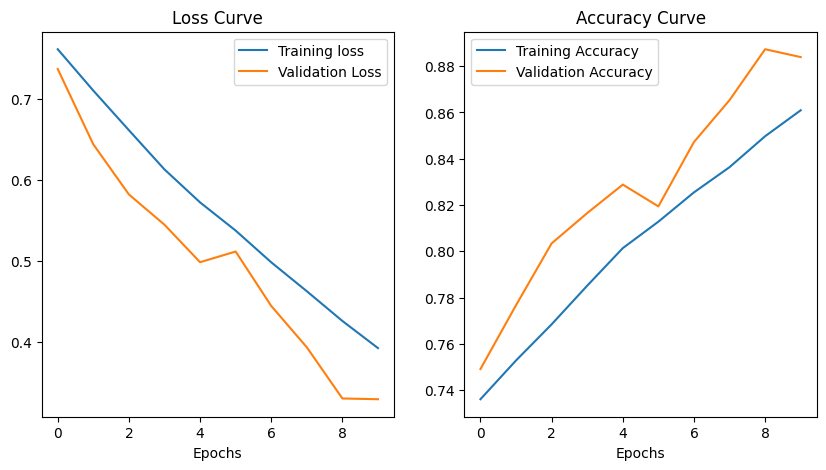

In [21]:
train_loss=history.history['loss']
val_loss=history.history['val_loss']
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(train_loss,label='Training loss')
plt.plot(val_loss,label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(122)
plt.plot(train_accuracy,label='Training Accuracy')
plt.plot(val_accuracy,label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.legend()

In [22]:
from tensorflow.keras.utils import to_categorical # type: ignore``
from tensorflow.keras.models import load_model # type: ignore

cnn_model.save('cnn_model.keras')
trained_cnn_model=load_model('cnn_model.keras')
trained_cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

### 4. Hyperparameter Tuning using Keras tuner

In [23]:
import tensorflow as tf
import keras_tuner
from keras_tuner import RandomSearch
from tensorflow.keras import layers, models, optimizers # type: ignore

def hp_cnn(hp):
    # list all hyperaparameters to tune
    learning_rate = hp.Choice("learning_rate",values=[1e-2, 1e-3, 1e-4, 1e-5])
    activation = hp.Choice('activation', ['relu', 'leaky_relu'])

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation=activation, input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation=activation),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation=activation),

        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')  # 10 classes
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [24]:
tuner = keras_tuner.RandomSearch(
    hp_cnn,
    objective='val_accuracy',
    max_trials=5,
    directory=r'D:\Advanced_Machine_Learning\Deep_Neural_Networks',
    project_name='tuned_cnn'
)


d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
tuner.search_space_summary()

Search space summary
Default search space size: 2
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001, 1e-05], 'ordered': True}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'leaky_relu'], 'ordered': False}


In [ ]:
tuner.search(X_train,y_train,epochs=10,validation_data=(X_val,y_val))

Trial 2 Complete [00h 09m 24s]
val_accuracy: 0.33079999685287476

Best val_accuracy So Far: 0.8931999802589417
Total elapsed time: 00h 15m 24s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
0.001             |0.001             |learning_rate
relu              |leaky_relu        |activation

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.4381 - loss: 1.5398 - val_accuracy: 0.5578 - val_loss: 1.2728
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5883 - loss: 1.1640 - val_accuracy: 0.6494 - val_loss: 1.0065
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6493 - loss: 1.0014 - val_accuracy: 0.6951 - val_loss: 0.8830
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21703s 14s/step - accuracy: 0.6862 - loss: 0.8954 - val_accuracy: 0.7154 - val_loss: 0.8197
Epoch 5/10
1450/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7219 - loss: 0.8044

In [ ]:
best_cnn=tuner.get_best_hyperparameters(num_trials=1)[0]

print(f'Best Learning rate: {best_cnn.get('learning_rate')}')

Best Learning rate: 0.001


Next we just need to retrain our model on the best hyperparameter...

In [24]:
tuned_cnn = tuner.hypermodel.build(best_cnn)
tuned_cnn.fit(X_train, y_train, 
          validation_data= (X_val,y_val), 
          epochs= 10)

d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4260 - loss: 1.5694 - val_accuracy: 0.5482 - val_loss: 1.2787
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5647 - loss: 1.2198 - val_accuracy: 0.6003 - val_loss: 1.1383
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6238 - loss: 1.0634 - val_accuracy: 0.6190 - val_loss: 1.0780
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6614 - loss: 0.9575 - val_accuracy: 0.6499 - val_loss: 0.9922
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.6943 - loss: 0.8766 - val_accuracy: 0.6588 - val_loss: 1.0070
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7150 - loss: 0.8124 - val_accuracy: 0.6655 - val_loss: 0.9548
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7369 - loss: 0.7551 - val_accuracy: 0.6845 - val_loss: 0.9197
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7543 -

Save the hypertuned model and now we are ready to put it to test on unseen data!!!

In [25]:
tuned_cnn.save('hypertuned_cnn_model.keras')

### 5. Model Evaluation on Tuned model

In [26]:
# load the optimized model
hypertuned_cnn_model=load_model('hypertuned_cnn_model.keras')

In [27]:
predictions = hypertuned_cnn_model.predict(X_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


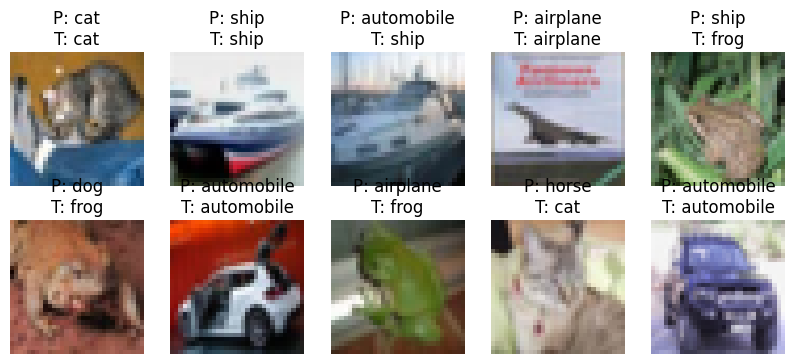

In [28]:
# Display test images with predicted labels
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i][0]]
    plt.title(f"P: {pred_label}\nT: {true_label}")
    plt.axis('off')
plt.show()

In [30]:
# Evaluate tuned model on test set
from sklearn.metrics import classification_report

probs_tuned = hypertuned_cnn_model.predict(X_test, verbose=0)
y_pred_tuned = np.argmax(probs_tuned, axis=1)

print("Tuned model classification report:")
print(classification_report(
    y_test, y_pred_tuned,
    labels=list(range(43)),
    target_names=class_names,
    zero_division=0
))

Tuned model classification report:
              precision    recall  f1-score   support

    airplane       0.40      0.73      0.51      1000
  automobile       0.50      0.84      0.63      1000
        bird       0.75      0.09      0.16      1000
         cat       0.35      0.21      0.27      1000
        deer       0.83      0.04      0.07      1000
         dog       0.48      0.54      0.50      1000
        frog       0.82      0.11      0.20      1000
       horse       0.53      0.62      0.57      1000
        ship       0.43      0.68      0.53      1000
       truck       0.40      0.70      0.51      1000

    accuracy                           0.45     10000
   macro avg       0.13      0.11      0.09     10000
weighted avg       0.55      0.45      0.39     10000



d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\sklearn\metrics\_classification.py:2964: UserWarning: labels size, 43, does not match size of target_names, 10
  warnings.warn(
